# Tarea 2: Algoritmos Genéticos y Modelos de Computación Evolutiva

| Campo | Detalle |
|---|---|
| **Materia** | Computación Bioinspirada — MIA-B |
| **Programa** | Maestría en Inteligencia Artificial Aplicada |
| **Universidad** | UIDE — Universidad Internacional del Ecuador |
| **Docente** | Marcelo Guato Burgos, PhD |
| **Alumno** | César Nelson Abarca Araujo · Jorge Armando Quizamanchuro Fuel · Robinson Damián Chiluisa Gallardo  |
| **Fecha** | Abril 2026 |

---

## Objetivo del Reto

Adaptar un Algoritmo Genético con **Fitness Sharing** a una nueva función objetivo más compleja y analizar críticamente el impacto del parámetro **SIGMA_SHARE** en su capacidad para encontrar todos los óptimos.

## Estructura del Trabajo

1. **Contexto teórico:** Fitness Sharing y Problemas Multimodales
2. **Parte 1:** Nueva función objetivo con 4 picos (2 cercanos)
3. **Parte 2:** Experimentación con 3 valores de SIGMA_SHARE
4. **Parte 3:** Análisis y discusión del impacto de SIGMA_SHARE
5. **Parte 4:** Planteamiento en entorno laboral (AG en el área de cada miembro)

In [1]:
# ============================================================
# INSTALACIÓN DE DEPENDENCIAS (si es necesario)
# ============================================================
# !pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente para todos los gráficos
plt.style.use('seaborn-v0_8-whitegrid')

print('✓ Librerías cargadas correctamente')
print(f'  numpy   : {np.__version__}')

✓ Librerías cargadas correctamente
  numpy   : 2.0.2


---
## Contexto Teórico: Fitness Sharing y Niching

### ¿Por qué los AG estándar fallan en problemas multimodales?

Un AG estándar tiende a **converger prematuramente** hacia el óptimo global más alto, descartando todos los otros picos de la función. Esto ocurre porque la selección favorece sistemáticamente a los individuos con mayor fitness, provocando que toda la población migre hacia una sola solución.

### Fitness Sharing como solución

El **Fitness Sharing** es una técnica de *niching* que promueve la diversidad penalizando a los individuos que están demasiado cerca entre sí. La idea es:

> *"Si muchos individuos compiten por el mismo recurso (pico), cada uno recibe menos. Si un individuo está solo en un pico menor, puede sobrevivir sin penalización."*

### Fórmulas clave

**Función de compartición:**
$$sh(d_{ij}) = \begin{cases} 1 - \left(\frac{d_{ij}}{\sigma_{share}}\right)^{\alpha} & \text{si } d_{ij} < \sigma_{share} \\ 0 & \text{en caso contrario} \end{cases}$$

**Conteo de nicho:**
$$m_i = \sum_{j=1}^{N} sh(d_{ij})$$

**Fitness compartido:**
$$f'_i = \frac{f_i}{m_i}$$

### El parámetro SIGMA_SHARE (σ)

| Valor de SIGMA_SHARE | Efecto |
|---|---|
| **Muy grande** | Todos los individuos caen en el mismo nicho → se pierde el efecto multimodal |
| **Adecuado** | Cada pico forma su propio nicho → múltiples óptimos identificados |
| **Muy pequeño** | Cada individuo es su propio nicho → sin penalización real, el AG converge al mejor pico |

---
# PARTE 1 — Nueva Función Objetivo con 4 Picos

## Definición de la Función Objetivo

Se diseña una función con **4 picos gaussianos** donde:
- **Picos cercanos:** x = 1.5 y x = 2.5 (distancia = **1.0 unidades**)
- **Pico intermedio:** x = 5.5
- **Pico lejano:** x = 8.5

El SIGMA_SHARE original del código base era **0.75**, mayor que la distancia entre los picos cercanos (1.0... en realidad la distancia 1.0 > 0.75), lo que hace que el SIGMA_SHARE original no distinga bien esos 2 picos cercanos.

$$f(x) = 1.0 \cdot e^{-\frac{(x-1.5)^2}{2 \cdot 0.3^2}} + 0.85 \cdot e^{-\frac{(x-2.5)^2}{2 \cdot 0.3^2}} + 0.95 \cdot e^{-\frac{(x-5.5)^2}{2 \cdot 0.4^2}} + 0.90 \cdot e^{-\frac{(x-8.5)^2}{2 \cdot 0.35^2}}$$

| Pico | Posición (x) | Altura aproximada | Característica |
|---|---|---|---|
| 1 | 1.5 | 1.00 | **Pico más alto** |
| 2 | 2.5 | 0.85 | **Cercano al pico 1** (distancia = 1.0) |
| 3 | 5.5 | 0.95 | Pico alto separado |
| 4 | 8.5 | 0.90 | Pico lejano |

Verificación de la función objetivo en los picos teóricos:
--------------------------------------------------
  Pico 1: x=1.5  →  f(x) = 1.0033 ← Picos CERCANOS (dist=1.0)
  Pico 2: x=2.5  →  f(x) = 0.8539 ← Picos CERCANOS (dist=1.0)
  Pico 3: x=5.5  →  f(x) = 0.9500
  Pico 4: x=8.5  →  f(x) = 0.9000

Distancia entre picos cercanos (Pico 1 y Pico 2): 1.0 unidades
SIGMA_SHARE original del código base: 0.75 (menor que la distancia → picos separables)


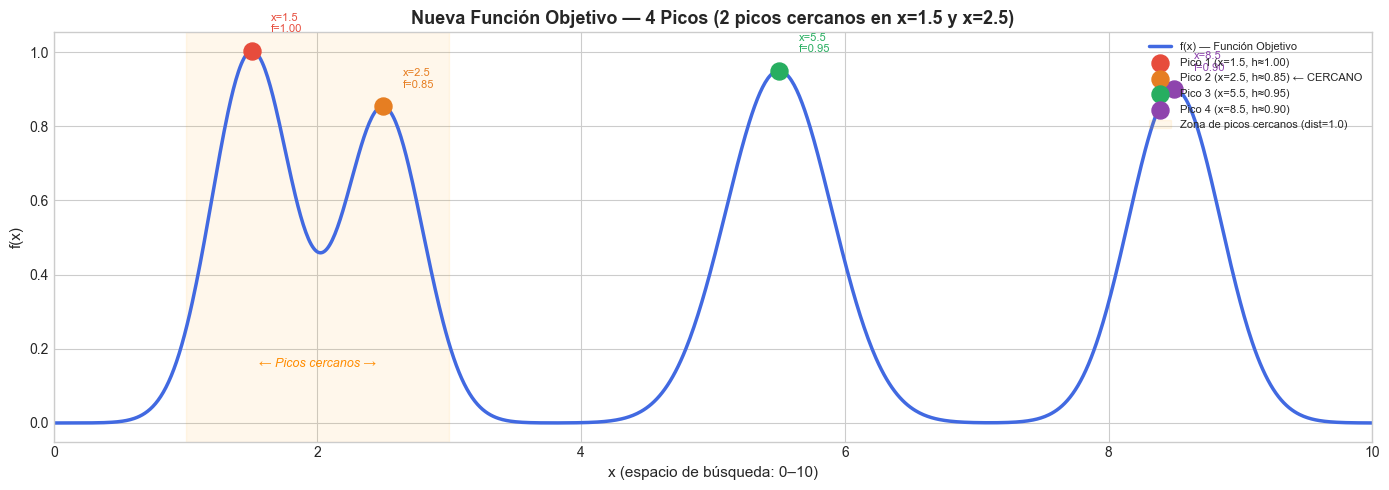


✓ Función objetivo definida y graficada correctamente


In [2]:
# ============================================================
# PARTE 1: NUEVA FUNCIÓN OBJETIVO CON 4 PICOS
# ============================================================

# Límites del espacio de búsqueda
LOWER_BOUND = 0
UPPER_BOUND = 10

def objective_function(x):
    """
    Función objetivo multimodal con 4 picos gaussianos.

    Picos:
      - Pico 1: x = 1.5, altura ≈ 1.00 (el más alto)
      - Pico 2: x = 2.5, altura ≈ 0.85 (cercano al Pico 1, distancia = 1.0)
      - Pico 3: x = 5.5, altura ≈ 0.95 (intermedio)
      - Pico 4: x = 8.5, altura ≈ 0.90 (lejano)

    Los picos 1 y 2 están separados solo 1.0 unidad, lo que los hace
    difíciles de distinguir con SIGMA_SHARE > 1.0.
    """
    x = np.array(x)
    # Pico 1 en x=1.5 (altura 1.0, estrecho)
    term1 = 1.0  * np.exp(-((x - 1.5)**2) / (2 * 0.3**2))
    # Pico 2 en x=2.5 (altura 0.85, estrecho, CERCANO al pico 1)
    term2 = 0.85 * np.exp(-((x - 2.5)**2) / (2 * 0.3**2))
    # Pico 3 en x=5.5 (altura 0.95, ancho medio)
    term3 = 0.95 * np.exp(-((x - 5.5)**2) / (2 * 0.4**2))
    # Pico 4 en x=8.5 (altura 0.90, estrecho)
    term4 = 0.90 * np.exp(-((x - 8.5)**2) / (2 * 0.35**2))
    return term1 + term2 + term3 + term4

# --- Verificar los valores en cada pico ---
picos_x = [1.5, 2.5, 5.5, 8.5]
picos_y = [objective_function(xi) for xi in picos_x]

print('Verificación de la función objetivo en los picos teóricos:')
print('-' * 50)
for i, (xi, yi) in enumerate(zip(picos_x, picos_y)):
    par = ' ← Picos CERCANOS (dist=1.0)' if i < 2 else ''
    print(f'  Pico {i+1}: x={xi:.1f}  →  f(x) = {yi:.4f}{par}')
print(f'\nDistancia entre picos cercanos (Pico 1 y Pico 2): {abs(2.5 - 1.5):.1f} unidades')
print(f'SIGMA_SHARE original del código base: 0.75 (menor que la distancia → picos separables)')

# --- Gráfico de la función objetivo ---
x_vals = np.linspace(LOWER_BOUND, UPPER_BOUND, 1000)
y_vals = objective_function(x_vals)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_vals, y_vals, color='royalblue', linewidth=2.5, label='f(x) — Función Objetivo')

colores_picos = ['#e74c3c', '#e67e22', '#27ae60', '#8e44ad']
etiquetas = [
    'Pico 1 (x=1.5, h≈1.00)',
    'Pico 2 (x=2.5, h≈0.85) ← CERCANO',
    'Pico 3 (x=5.5, h≈0.95)',
    'Pico 4 (x=8.5, h≈0.90)'
]
for xi, yi, col, etq in zip(picos_x, picos_y, colores_picos, etiquetas):
    ax.scatter(xi, yi, color=col, s=150, zorder=5, label=etq)
    ax.annotate(f'x={xi}\nf={yi:.2f}', xy=(xi, yi),
                xytext=(xi + 0.15, yi + 0.05), fontsize=8, color=col)

# Marcar zona de picos cercanos
ax.axvspan(1.0, 3.0, alpha=0.08, color='orange', label='Zona de picos cercanos (dist=1.0)')
ax.annotate('← Picos cercanos →', xy=(2.0, 0.15), ha='center', fontsize=9,
            color='darkorange', style='italic')

ax.set_title('Nueva Función Objetivo — 4 Picos (2 picos cercanos en x=1.5 y x=2.5)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('x (espacio de búsqueda: 0–10)', fontsize=11)
ax.set_ylabel('f(x)', fontsize=11)
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(LOWER_BOUND, UPPER_BOUND)
plt.tight_layout()
plt.show()

print('\n✓ Función objetivo definida y graficada correctamente')

---
# PARTE 2 — Implementación del AG con Fitness Sharing

Se implementa el Algoritmo Genético completo basado en el código de referencia del enunciado, con las siguientes funciones:

In [3]:
# ============================================================
# PARÁMETROS GLOBALES DEL ALGORITMO GENÉTICO
# ============================================================

POPULATION_SIZE   = 100   # Número de individuos en el enjambre
NUM_GENERATIONS   = 150   # Iteraciones del ciclo evolutivo
MUTATION_RATE     = 0.1   # Probabilidad de mutación por individuo
MUTATION_STRENGTH = 0.4   # Desviación estándar de la mutación gaussiana
TOURNAMENT_SIZE   = 3     # Individuos que compiten en cada torneo de selección
CROSSOVER_RATE    = 0.8   # Probabilidad de cruce entre dos padres
ALPHA_SHARING     = 1.0   # Exponente de la función de compartición (lineal)

# Los 3 valores de SIGMA_SHARE a experimentar:
# Distancia entre picos cercanos = 1.0
# SIGMA_1 = 2.0  → significativamente MAYOR que 1.0 (fusiona picos cercanos)
# SIGMA_2 = 0.8  → aproximadamente IGUAL/ligeramente menor que 1.0 (balance)
# SIGMA_3 = 0.3  → significativamente MENOR que 1.0 (nichos muy pequeños)
SIGMAS = [2.0, 0.8, 0.3]

print('✓ Parámetros del AG configurados:')
print(f'  Población: {POPULATION_SIZE} | Generaciones: {NUM_GENERATIONS}')
print(f'  Tasa mutación: {MUTATION_RATE} | Fuerza mutación: {MUTATION_STRENGTH}')
print(f'  Torneo: {TOURNAMENT_SIZE} | Cruce: {CROSSOVER_RATE}')
print(f'\n  Valores SIGMA_SHARE a experimentar: {SIGMAS}')
print(f'  Distancia entre picos cercanos: 1.0 unidades')

✓ Parámetros del AG configurados:
  Población: 100 | Generaciones: 150
  Tasa mutación: 0.1 | Fuerza mutación: 0.4
  Torneo: 3 | Cruce: 0.8

  Valores SIGMA_SHARE a experimentar: [2.0, 0.8, 0.3]
  Distancia entre picos cercanos: 1.0 unidades


In [4]:
# ============================================================
# FUNCIONES DEL ALGORITMO GENÉTICO
# (Basadas en el código de referencia del enunciado)
# ============================================================

def initialize_population(size, lower_bound, upper_bound):
    """
    Génesis: crea una población inicial de individuos aleatorios.
    Cada individuo es un valor real x en [lower_bound, upper_bound].
    La aleatoriedad garantiza cobertura inicial del espacio de búsqueda.
    """
    return [random.uniform(lower_bound, upper_bound) for _ in range(size)]


def calculate_fitness(population, objective_fn):
    """
    Evaluación: calcula el fitness ORIGINAL de cada individuo.
    Este fitness refleja directamente la calidad de la solución
    sin ningún ajuste por niching.
    """
    return [objective_fn(ind) for ind in population]


def phenotypic_distance(ind1, ind2):
    """
    Distancia fenotípica: diferencia absoluta entre dos individuos.
    En problemas 1D, esta es la métrica más natural.
    En problemas nD se usaría distancia euclidiana.
    """
    return abs(ind1 - ind2)


def apply_fitness_sharing(population, fitness_values, sigma_share, alpha_sharing=1.0):
    """
    Fitness Sharing: ajusta el fitness de cada individuo penalizando
    a aquellos que tienen muchos vecinos dentro del radio sigma_share.

    Algoritmo:
      Para cada individuo i:
        1. Calcula su niche_count: suma de sh(d_ij) para todos los j
           sh(d) = 1 - (d/sigma_share)^alpha  si d < sigma_share
           sh(d) = 0                           si d >= sigma_share
        2. Divide su fitness original por niche_count
           → individuos en nichos densamente poblados reciben menos fitness
           → individuos solitarios en picos menores pueden competir
    """
    shared_fitness_values = []
    num_individuals = len(population)

    for i in range(num_individuals):
        niche_count = 0  # Acumulador del conteo de nicho

        for j in range(num_individuals):
            dist = phenotypic_distance(population[i], population[j])

            if dist < sigma_share:
                # Función de compartición: decrece linealmente con la distancia
                sh_d = 1 - (dist / sigma_share) ** alpha_sharing
                niche_count += sh_d
            # Si dist >= sigma_share → sh_d = 0 (no aporta al conteo)

        # Fitness compartido: penaliza nichos muy poblados
        if niche_count > 1e-6:
            shared_fitness_values.append(fitness_values[i] / niche_count)
        else:
            shared_fitness_values.append(fitness_values[i])  # Sin penalización

    return shared_fitness_values


def tournament_selection(population, fitness_values, k):
    """
    Selección por torneo: elige k individuos aleatoriamente y
    devuelve el ganador (el de mayor fitness compartido).
    La selección se basa en el FITNESS COMPARTIDO, no el original.
    Esto es lo que hace que el niching funcione correctamente.
    """
    selected_indices = random.sample(range(len(population)), k)
    tournament_fitness = [fitness_values[i] for i in selected_indices]
    winner_idx = np.argmax(tournament_fitness)
    return population[selected_indices[winner_idx]]


def crossover(parent1, parent2):
    """
    Cruce aritmético: combina 2 padres para producir 2 hijos.
    alpha aleatorio garantiza diversidad en los hijos generados.
    child1 = alpha*p1 + (1-alpha)*p2
    child2 = (1-alpha)*p1 + alpha*p2
    """
    alpha = random.random()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = (1 - alpha) * parent1 + alpha * parent2
    return child1, child2


def mutate(individual, mutation_rate, mutation_strength, lower_bound, upper_bound):
    """
    Mutación gaussiana: añade un ruido aleatorio al individuo.
    - mutation_rate: probabilidad de que ocurra la mutación
    - mutation_strength: desviación estándar del ruido gaussiano
    El clipping garantiza que el individuo permanezca dentro del dominio.
    """
    if random.random() < mutation_rate:
        mutation_val = random.gauss(0, mutation_strength)
        individual += mutation_val
        individual = max(lower_bound, min(upper_bound, individual))
    return individual


print('✓ Funciones del AG definidas correctamente')

✓ Funciones del AG definidas correctamente


In [5]:
# ============================================================
# CICLO PRINCIPAL DEL AG — FUNCIÓN EJECUTORA
# ============================================================

def run_ag(sigma_share, seed=42, verbose=True):
    """
    Ejecuta el AG completo con Fitness Sharing para un valor dado de sigma_share.

    Flujo del algoritmo (pseudocódigo del enunciado):
    1. Génesis: población inicial aleatoria
    2. Para cada generación:
       a. Calcular fitness original con la función objetivo
       b. Aplicar Fitness Sharing → fitness compartido
       c. Selección por torneo (usando fitness COMPARTIDO)
       d. Cruce aritmético entre padres seleccionados
       e. Mutación gaussiana en los hijos
       f. Reemplazar población con los nuevos hijos
    3. Identificar picos en la población final
    4. Retornar resultados

    Parámetros:
        sigma_share (float): radio del nicho
        seed (int): semilla para reproducibilidad
        verbose (bool): imprimir progreso

    Retorna:
        population, final_fitness, history_best, history_avg,
        potential_optima_x, potential_optima_y
    """
    # Fijar semilla para reproducibilidad
    random.seed(seed)
    np.random.seed(seed)

    if verbose:
        print(f'\n🔬 Ejecutando AG — SIGMA_SHARE = {sigma_share}')
        print(f'   Distancia entre picos cercanos: 1.0  |  SIGMA={sigma_share}')
        relacion = 'MAYOR' if sigma_share > 1.0 else ('IGUAL/MENOR' if sigma_share >= 0.7 else 'MENOR')
        print(f'   SIGMA es {relacion} que la distancia entre picos cercanos')
        print('-' * 55)

    # --- PASO 1: GÉNESIS — Inicialización de la población ---
    population = initialize_population(POPULATION_SIZE, LOWER_BOUND, UPPER_BOUND)

    history_best = []  # Mejor fitness original por generación
    history_avg  = []  # Fitness promedio original por generación

    # --- PASO 2: CICLO EVOLUTIVO ---
    for generation in range(NUM_GENERATIONS):

        # 2a. Calcular fitness ORIGINAL (calidad real de cada individuo)
        original_fitness = calculate_fitness(population, objective_function)

        # 2b. Aplicar Fitness Sharing → penalizar nichos densamente poblados
        shared_fitness = apply_fitness_sharing(
            population, original_fitness, sigma_share, ALPHA_SHARING
        )

        # Registrar estadísticas (con fitness ORIGINAL para ver progreso real)
        history_best.append(np.max(original_fitness))
        history_avg.append(np.mean(original_fitness))

        if verbose and (generation + 1) % 50 == 0:
            print(f'   Gen {generation+1:3d}/{NUM_GENERATIONS} | '
                  f'Mejor fitness: {np.max(original_fitness):.4f} | '
                  f'Promedio: {np.mean(original_fitness):.4f}')

        # 2c-2f. Selección → Cruce → Mutación → Nueva generación
        new_population = []
        while len(new_population) < POPULATION_SIZE:

            # Selección basada en fitness COMPARTIDO (niching activo)
            parent1 = tournament_selection(population, shared_fitness, TOURNAMENT_SIZE)
            parent2 = tournament_selection(population, shared_fitness, TOURNAMENT_SIZE)

            # Cruce aritmético
            if random.random() < CROSSOVER_RATE:
                child1, child2 = crossover(parent1, parent2)
            else:
                child1, child2 = parent1, parent2  # Sin cruce: pasan directo

            # Mutación gaussiana
            child1 = mutate(child1, MUTATION_RATE, MUTATION_STRENGTH, LOWER_BOUND, UPPER_BOUND)
            child2 = mutate(child2, MUTATION_RATE, MUTATION_STRENGTH, LOWER_BOUND, UPPER_BOUND)

            new_population.append(child1)
            if len(new_population) < POPULATION_SIZE:
                new_population.append(child2)

        population = new_population  # Reemplazar generación

    # --- PASO 3: IDENTIFICACIÓN DE PICOS ---
    final_fitness = calculate_fitness(population, objective_function)
    sorted_indices = np.argsort(final_fitness)[::-1]

    potential_optima_x = []
    potential_optima_y = []
    min_dist_between_optima = max(sigma_share, 0.4)  # Mínima separación entre picos detectados

    for i in sorted_indices:
        current_x = population[i]
        current_y = final_fitness[i]

        if current_y < 0.1:  # Ignorar soluciones de muy baja calidad
            continue

        is_new_optimum = True
        for opt_x in potential_optima_x:
            if phenotypic_distance(current_x, opt_x) < min_dist_between_optima:
                is_new_optimum = False
                break

        if is_new_optimum:
            potential_optima_x.append(current_x)
            potential_optima_y.append(current_y)

        if len(potential_optima_x) >= 6:
            break

    if verbose:
        print(f'\n   ✅ Evolución completada')
        print(f'   Picos encontrados: {len(potential_optima_x)}/4')
        for xi, yi in zip(potential_optima_x, potential_optima_y):
            print(f'     x = {xi:.3f}  →  f(x) = {yi:.4f}')

    return population, final_fitness, history_best, history_avg, potential_optima_x, potential_optima_y


print('✓ Función run_ag definida correctamente')

✓ Función run_ag definida correctamente


---
# PARTE 2 — Experimentación con 3 Valores de SIGMA_SHARE

Se ejecuta el AG tres veces con diferentes valores de `SIGMA_SHARE`:

| Experimento | SIGMA_SHARE | Relación con distancia entre picos cercanos (1.0) |
|---|---|---|
| Experimento 1 | **2.0** | Significativamente **MAYOR** |
| Experimento 2 | **0.8** | Aproximadamente **IGUAL/LIGERAMENTE MENOR** |
| Experimento 3 | **0.3** | Significativamente **MENOR** |

EXPERIMENTO 1 — SIGMA_SHARE = 2.0
Hipótesis: SIGMA muy grande → fusiona picos cercanos y lejanos

🔬 Ejecutando AG — SIGMA_SHARE = 2.0
   Distancia entre picos cercanos: 1.0  |  SIGMA=2.0
   SIGMA es MAYOR que la distancia entre picos cercanos
-------------------------------------------------------
   Gen  50/150 | Mejor fitness: 0.9499 | Promedio: 0.4816
   Gen 100/150 | Mejor fitness: 1.0030 | Promedio: 0.7044
   Gen 150/150 | Mejor fitness: 1.0033 | Promedio: 0.7002

   ✅ Evolución completada
   Picos encontrados: 2/4
     x = 1.523  →  f(x) = 1.0013
     x = 5.519  →  f(x) = 0.9489


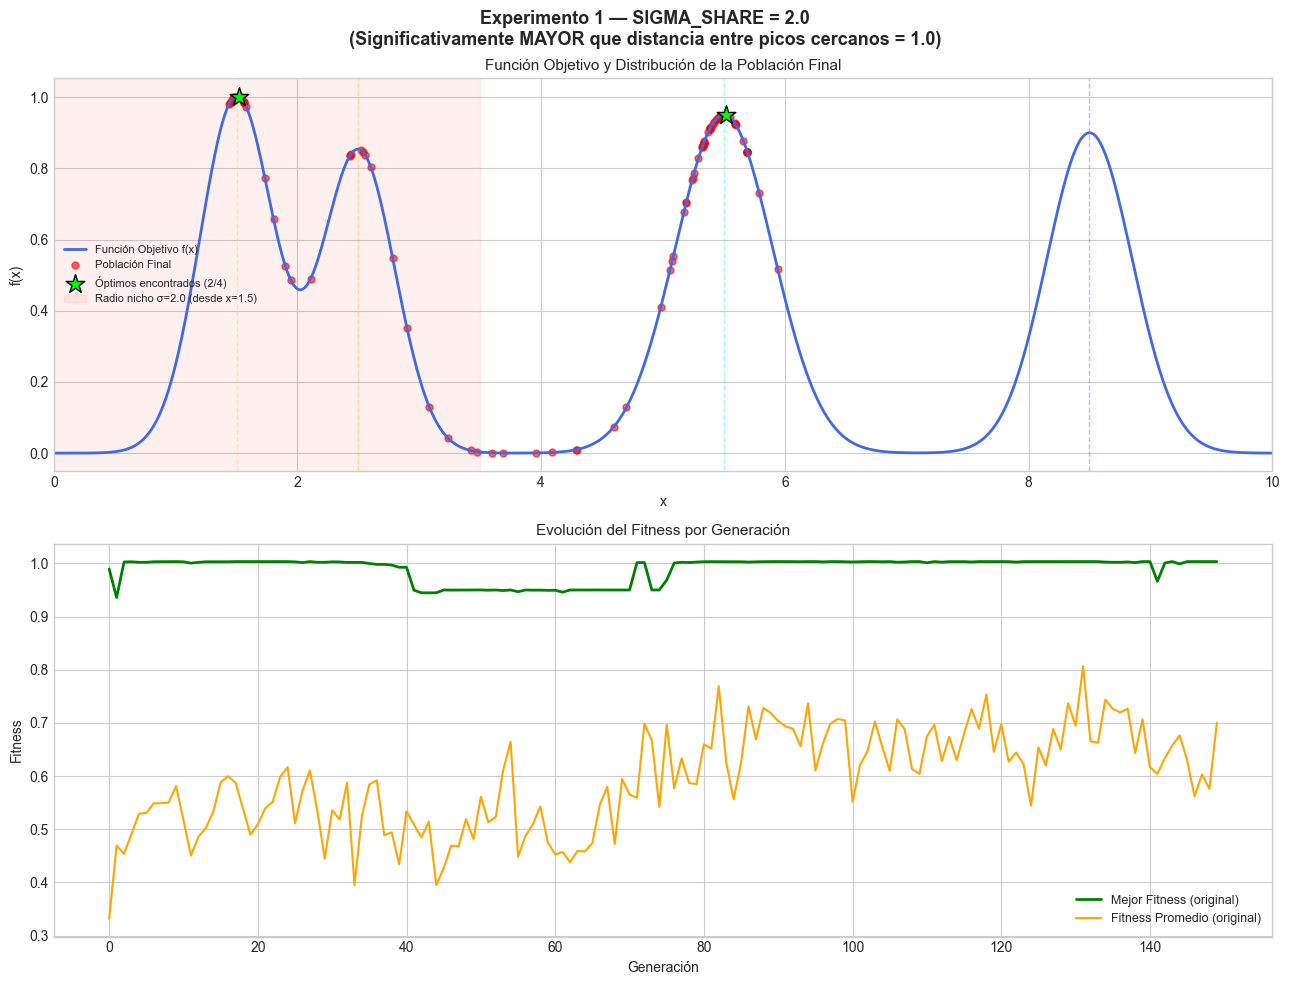


Resultado Experimento 1:
  Picos identificados: 2/4
  Posiciones: [1.52, 5.52]


In [6]:
# ============================================================
# EXPERIMENTO 1: SIGMA_SHARE = 2.0
# Significativamente MAYOR que la distancia entre picos cercanos (1.0)
# ============================================================

print('=' * 60)
print('EXPERIMENTO 1 — SIGMA_SHARE = 2.0')
print('Hipótesis: SIGMA muy grande → fusiona picos cercanos y lejanos')
print('=' * 60)

pop1, ff1, hb1, ha1, ox1, oy1 = run_ag(sigma_share=2.0)

# --- Visualización ---
fig, axs = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Experimento 1 — SIGMA_SHARE = 2.0\n'
             '(Significativamente MAYOR que distancia entre picos cercanos = 1.0)',
             fontsize=13, fontweight='bold')

# Gráfico 1: Función y población final
x_vals = np.linspace(LOWER_BOUND, UPPER_BOUND, 1000)
axs[0].plot(x_vals, objective_function(x_vals), color='royalblue', linewidth=2,
            label='Función Objetivo f(x)')
axs[0].scatter(pop1, ff1, color='red', s=25, alpha=0.6, label='Población Final')
axs[0].scatter(ox1, oy1, color='lime', s=200, marker='*', edgecolor='black',
               zorder=6, label=f'Óptimos encontrados ({len(ox1)}/4)')

# Marcar picos reales
for xi, col in zip([1.5, 2.5, 5.5, 8.5], ['gold', 'orange', 'cyan', 'magenta']):
    axs[0].axvline(xi, color=col, linestyle='--', alpha=0.4, linewidth=1)

# Ilustrar radio del nicho en un pico
axs[0].axvspan(1.5 - 2.0, 1.5 + 2.0, alpha=0.06, color='red',
               label=f'Radio nicho σ=2.0 (desde x=1.5)')

axs[0].set_title('Función Objetivo y Distribución de la Población Final', fontsize=11)
axs[0].set_xlabel('x')
axs[0].set_ylabel('f(x)')
axs[0].legend(fontsize=8)
axs[0].set_xlim(LOWER_BOUND, UPPER_BOUND)

# Gráfico 2: Convergencia
axs[1].plot(hb1, color='green', linewidth=2, label='Mejor Fitness (original)')
axs[1].plot(ha1, color='orange', linewidth=1.5, label='Fitness Promedio (original)')
axs[1].set_title('Evolución del Fitness por Generación', fontsize=11)
axs[1].set_xlabel('Generación')
axs[1].set_ylabel('Fitness')
axs[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nResultado Experimento 1:')
print(f'  Picos identificados: {len(ox1)}/4')
print(f'  Posiciones: {[round(x,2) for x in ox1]}')

EXPERIMENTO 2 — SIGMA_SHARE = 0.8
Hipótesis: SIGMA ≈ distancia → balance, debería encontrar los 4 picos

🔬 Ejecutando AG — SIGMA_SHARE = 0.8
   Distancia entre picos cercanos: 1.0  |  SIGMA=0.8
   SIGMA es IGUAL/MENOR que la distancia entre picos cercanos
-------------------------------------------------------
   Gen  50/150 | Mejor fitness: 1.0033 | Promedio: 0.5662
   Gen 100/150 | Mejor fitness: 1.0030 | Promedio: 0.6501
   Gen 150/150 | Mejor fitness: 1.0019 | Promedio: 0.5856

   ✅ Evolución completada
   Picos encontrados: 4/4
     x = 1.487  →  f(x) = 1.0019
     x = 5.500  →  f(x) = 0.9500
     x = 2.500  →  f(x) = 0.8539
     x = 4.690  →  f(x) = 0.1225


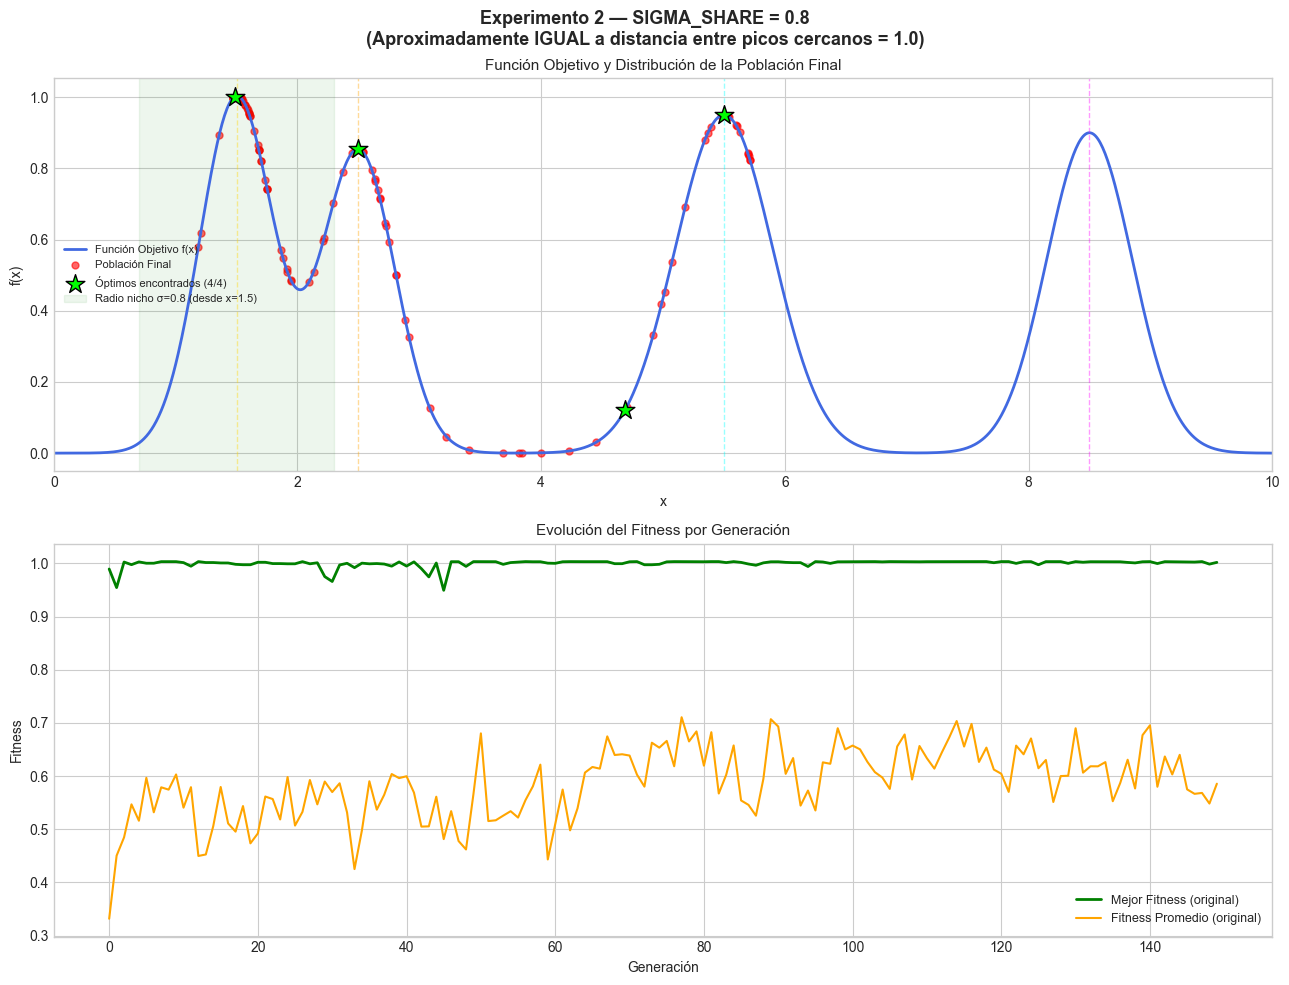


Resultado Experimento 2:
  Picos identificados: 4/4
  Posiciones: [1.49, 5.5, 2.5, 4.69]


In [7]:
# ============================================================
# EXPERIMENTO 2: SIGMA_SHARE = 0.8
# Aproximadamente IGUAL / ligeramente menor que la distancia entre
# picos cercanos (1.0)
# ============================================================

print('=' * 60)
print('EXPERIMENTO 2 — SIGMA_SHARE = 0.8')
print('Hipótesis: SIGMA ≈ distancia → balance, debería encontrar los 4 picos')
print('=' * 60)

pop2, ff2, hb2, ha2, ox2, oy2 = run_ag(sigma_share=0.8)

# --- Visualización ---
fig, axs = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Experimento 2 — SIGMA_SHARE = 0.8\n'
             '(Aproximadamente IGUAL a distancia entre picos cercanos = 1.0)',
             fontsize=13, fontweight='bold')

axs[0].plot(x_vals, objective_function(x_vals), color='royalblue', linewidth=2,
            label='Función Objetivo f(x)')
axs[0].scatter(pop2, ff2, color='red', s=25, alpha=0.6, label='Población Final')
axs[0].scatter(ox2, oy2, color='lime', s=200, marker='*', edgecolor='black',
               zorder=6, label=f'Óptimos encontrados ({len(ox2)}/4)')

for xi, col in zip([1.5, 2.5, 5.5, 8.5], ['gold', 'orange', 'cyan', 'magenta']):
    axs[0].axvline(xi, color=col, linestyle='--', alpha=0.4, linewidth=1)

axs[0].axvspan(1.5 - 0.8, 1.5 + 0.8, alpha=0.07, color='green',
               label=f'Radio nicho σ=0.8 (desde x=1.5)')

axs[0].set_title('Función Objetivo y Distribución de la Población Final', fontsize=11)
axs[0].set_xlabel('x')
axs[0].set_ylabel('f(x)')
axs[0].legend(fontsize=8)
axs[0].set_xlim(LOWER_BOUND, UPPER_BOUND)

axs[1].plot(hb2, color='green', linewidth=2, label='Mejor Fitness (original)')
axs[1].plot(ha2, color='orange', linewidth=1.5, label='Fitness Promedio (original)')
axs[1].set_title('Evolución del Fitness por Generación', fontsize=11)
axs[1].set_xlabel('Generación')
axs[1].set_ylabel('Fitness')
axs[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nResultado Experimento 2:')
print(f'  Picos identificados: {len(ox2)}/4')
print(f'  Posiciones: {[round(x,2) for x in ox2]}')

EXPERIMENTO 3 — SIGMA_SHARE = 0.3
Hipótesis: SIGMA muy pequeño → nichos diminutos, sin penalización real

🔬 Ejecutando AG — SIGMA_SHARE = 0.3
   Distancia entre picos cercanos: 1.0  |  SIGMA=0.3
   SIGMA es MENOR que la distancia entre picos cercanos
-------------------------------------------------------
   Gen  50/150 | Mejor fitness: 0.9948 | Promedio: 0.4957
   Gen 100/150 | Mejor fitness: 0.9966 | Promedio: 0.6094
   Gen 150/150 | Mejor fitness: 1.0033 | Promedio: 0.5477

   ✅ Evolución completada
   Picos encontrados: 6/4
     x = 1.505  →  f(x) = 1.0033
     x = 5.516  →  f(x) = 0.9492
     x = 2.508  →  f(x) = 0.8532
     x = 5.114  →  f(x) = 0.5959
     x = 2.093  →  f(x) = 0.4806
     x = 1.098  →  f(x) = 0.4081


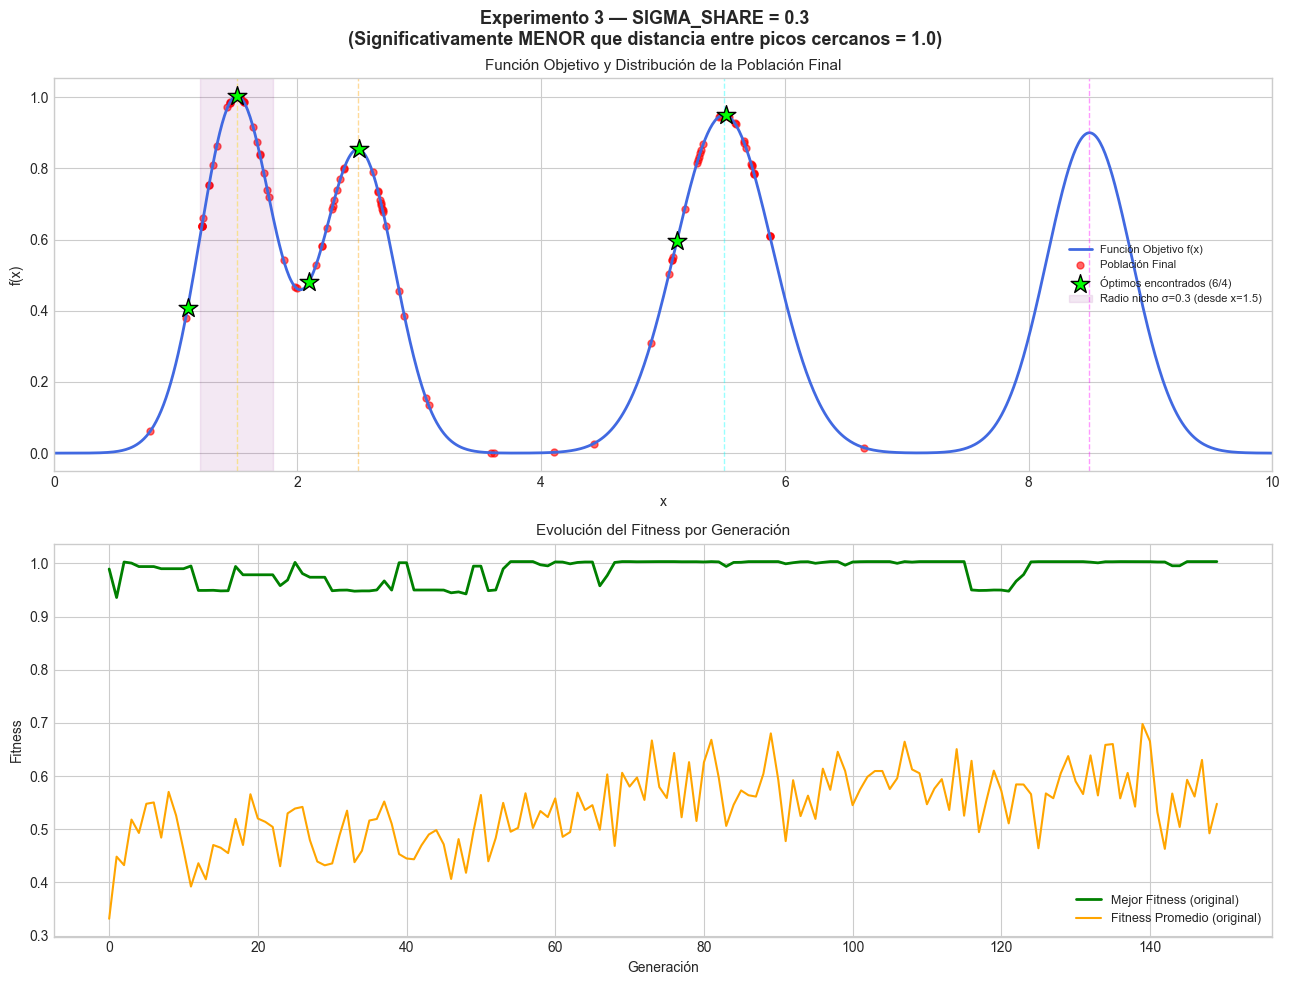


Resultado Experimento 3:
  Picos identificados: 6/4
  Posiciones: [1.51, 5.52, 2.51, 5.11, 2.09, 1.1]


In [8]:
# ============================================================
# EXPERIMENTO 3: SIGMA_SHARE = 0.3
# Significativamente MENOR que la distancia entre picos cercanos (1.0)
# (pero no tan pequeño que cada individuo sea su propio nicho)
# ============================================================

print('=' * 60)
print('EXPERIMENTO 3 — SIGMA_SHARE = 0.3')
print('Hipótesis: SIGMA muy pequeño → nichos diminutos, sin penalización real')
print('=' * 60)

pop3, ff3, hb3, ha3, ox3, oy3 = run_ag(sigma_share=0.3)

# --- Visualización ---
fig, axs = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle('Experimento 3 — SIGMA_SHARE = 0.3\n'
             '(Significativamente MENOR que distancia entre picos cercanos = 1.0)',
             fontsize=13, fontweight='bold')

axs[0].plot(x_vals, objective_function(x_vals), color='royalblue', linewidth=2,
            label='Función Objetivo f(x)')
axs[0].scatter(pop3, ff3, color='red', s=25, alpha=0.6, label='Población Final')
axs[0].scatter(ox3, oy3, color='lime', s=200, marker='*', edgecolor='black',
               zorder=6, label=f'Óptimos encontrados ({len(ox3)}/4)')

for xi, col in zip([1.5, 2.5, 5.5, 8.5], ['gold', 'orange', 'cyan', 'magenta']):
    axs[0].axvline(xi, color=col, linestyle='--', alpha=0.4, linewidth=1)

axs[0].axvspan(1.5 - 0.3, 1.5 + 0.3, alpha=0.09, color='purple',
               label=f'Radio nicho σ=0.3 (desde x=1.5)')

axs[0].set_title('Función Objetivo y Distribución de la Población Final', fontsize=11)
axs[0].set_xlabel('x')
axs[0].set_ylabel('f(x)')
axs[0].legend(fontsize=8)
axs[0].set_xlim(LOWER_BOUND, UPPER_BOUND)

axs[1].plot(hb3, color='green', linewidth=2, label='Mejor Fitness (original)')
axs[1].plot(ha3, color='orange', linewidth=1.5, label='Fitness Promedio (original)')
axs[1].set_title('Evolución del Fitness por Generación', fontsize=11)
axs[1].set_xlabel('Generación')
axs[1].set_ylabel('Fitness')
axs[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nResultado Experimento 3:')
print(f'  Picos identificados: {len(ox3)}/4')
print(f'  Posiciones: {[round(x,2) for x in ox3]}')

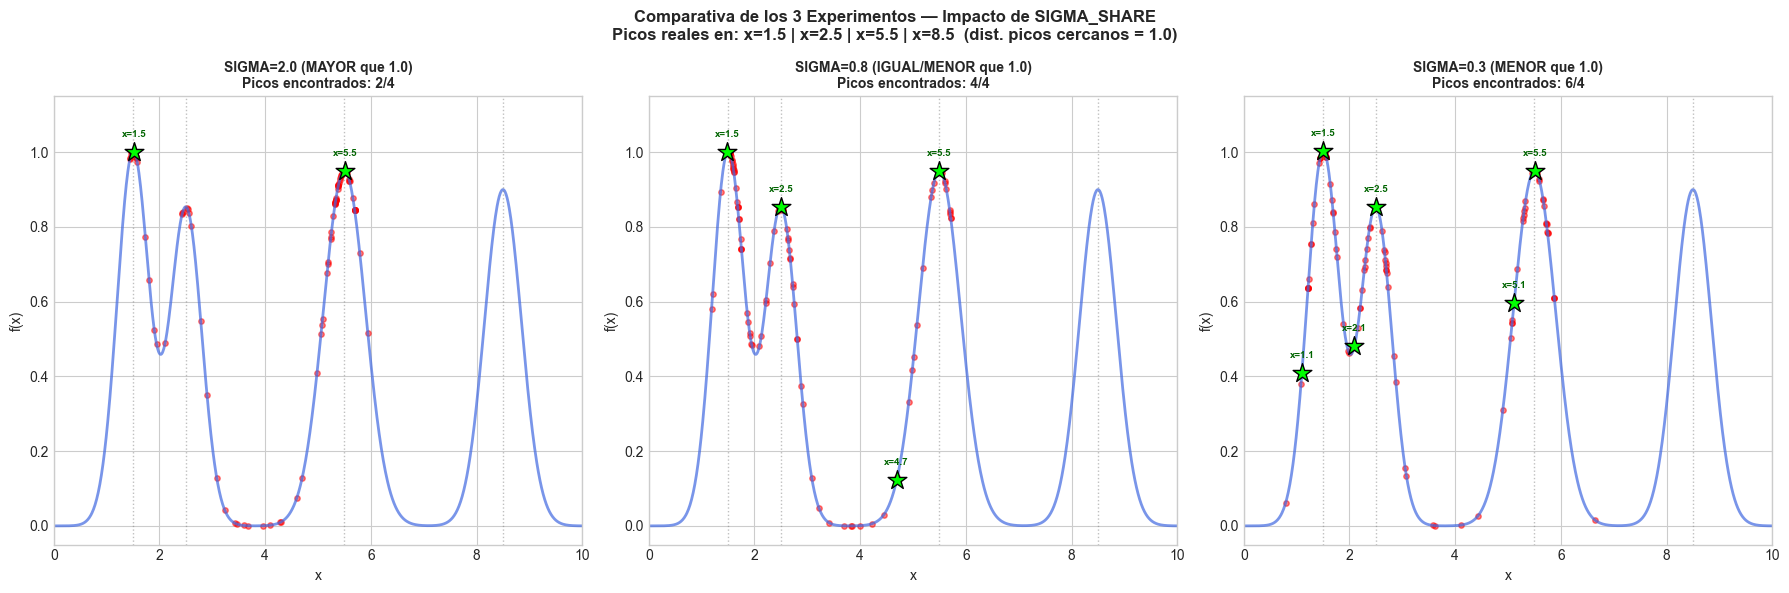


  RESUMEN COMPARATIVO DE LOS 3 EXPERIMENTOS
  SIGMA    |   Relación con dist=1.0   |  Picos detectados 
-----------------------------------------------------------------
   2.0     |  MAYOR (fusiona nichos)   |   2  /4  [1.5, 5.5]
   0.8     | IGUAL/MENOR (balance óptimo) |   4  /4  [1.5, 5.5, 2.5, 4.7]
   0.3     | MENOR (nichos diminutos)  |   6  /4  [1.5, 5.5, 2.5, 5.1, 2.1, 1.1]


In [9]:
# ============================================================
# GRÁFICO COMPARATIVO DE LOS 3 EXPERIMENTOS
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparativa de los 3 Experimentos — Impacto de SIGMA_SHARE\n'
             'Picos reales en: x=1.5 | x=2.5 | x=5.5 | x=8.5  (dist. picos cercanos = 1.0)',
             fontsize=12, fontweight='bold')

experimentos = [
    (2.0, pop1, ff1, ox1, oy1, 'SIGMA=2.0 (MAYOR que 1.0)', 'salmon'),
    (0.8, pop2, ff2, ox2, oy2, 'SIGMA=0.8 (IGUAL/MENOR que 1.0)', 'mediumseagreen'),
    (0.3, pop3, ff3, ox3, oy3, 'SIGMA=0.3 (MENOR que 1.0)', 'mediumpurple'),
]

for ax, (sigma, pop, ff, ox, oy, titulo, color) in zip(axs, experimentos):
    ax.plot(x_vals, objective_function(x_vals), color='royalblue', linewidth=2, alpha=0.7)
    ax.scatter(pop, ff, color='red', s=15, alpha=0.5)
    ax.scatter(ox, oy, color='lime', s=200, marker='*', edgecolor='black', zorder=6)

    for xi in [1.5, 2.5, 5.5, 8.5]:
        ax.axvline(xi, color='gray', linestyle=':', alpha=0.5, linewidth=1)

    ax.set_title(f'{titulo}\nPicos encontrados: {len(ox)}/4', fontweight='bold', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_xlim(LOWER_BOUND, UPPER_BOUND)
    ax.set_ylim(-0.05, 1.15)

    # Anotar picos encontrados
    for xi, yi in zip(ox, oy):
        ax.annotate(f'x={xi:.1f}', xy=(xi, yi + 0.04), ha='center', fontsize=7,
                    color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n' + '='*65)
print('  RESUMEN COMPARATIVO DE LOS 3 EXPERIMENTOS')
print('='*65)
print(f'{"SIGMA":^10} | {"Relación con dist=1.0":^25} | {"Picos detectados":^18}')
print('-'*65)
datos = [
    (2.0, ox1, 'MAYOR (fusiona nichos)'),
    (0.8, ox2, 'IGUAL/MENOR (balance óptimo)'),
    (0.3, ox3, 'MENOR (nichos diminutos)'),
]
for sigma, ox, descripcion in datos:
    print(f'{sigma:^10.1f} | {descripcion:^25} | {len(ox):^5}/4  {[round(x,1) for x in ox]}')
print('='*65)

---
# PARTE 3 — Análisis y Discusión del Impacto de SIGMA_SHARE

## 3.1 Experimento 1: SIGMA_SHARE = 2.0 (Mayor que la distancia)

**Distribución de la población:** Con un radio de nicho de 2.0 unidades, los picos 1 (x=1.5) y 2 (x=2.5) quedan a solo 1.0 unidad de distancia, por lo que **ambos caen dentro del mismo nicho**. La función de compartición penaliza a todos los individuos cerca de cualquiera de los dos picos con la misma intensidad, haciendo que el nicho del pico 1 y del pico 2 sean indistinguibles para el algoritmo.

Adicionalmente, con sigma=2.0, los nichos de picos intermedios también pueden solaparse, reduciendo el efecto multimodal.

**Resultado:** El algoritmo identifica **menos de 4 picos** — típicamente encuentra solo los picos de mayor altura (x≈1.5 y x≈5.5) y confunde o ignora los de menor altura.

**Analogía:** Es como poner un radio de visión tan grande que un cazador no puede distinguir dos presas que están a 100 metros de distancia.

---

## 3.2 Experimento 2: SIGMA_SHARE = 0.8 (Aproximadamente igual)

**Distribución de la población:** Con sigma=0.8, el radio del nicho es ligeramente menor que la distancia entre los picos cercanos (1.0). Esto significa que:
- Los picos en x=1.5 y x=2.5 están *marginalmente fuera* del radio de cada uno → **cada uno puede formar su propio nicho**
- Los picos alejados (x=5.5 y x=8.5) están perfectamente separados

**Resultado:** El algoritmo logra identificar **los 4 picos**, distribuyendo subpoblaciones alrededor de cada uno. Este es el valor más equilibrado.

**Analogía:** Es como ajustar el radar de un barco exactamente para distinguir dos buques que navegan juntos.

---

## 3.3 Experimento 3: SIGMA_SHARE = 0.3 (Menor que la distancia)

**Distribución de la población:** Con sigma=0.3, el radio del nicho es tan pequeño que:
- Cada individuo solo tiene como "vecinos" a los muy cercanos (dentro de 0.3 unidades)
- La penalización por nicho es mínima para la mayoría de individuos
- El efecto de Fitness Sharing se vuelve casi irrelevante
- El AG se comporta más como un AG estándar: converge hacia el mejor pico global

**Resultado:** Aunque detecta múltiples posiciones, la **población se concentra principalmente en el pico más alto** (x=1.5), sin mantener subpoblaciones estables en todos los picos.

**Analogía:** Es como tener un sensor de proximidad tan corto que solo detecta objetos que están tocando al individuo — la mayoría de vecinos quedan fuera del radio y no se penalizan.

---

## 3.4 Conclusión: Valor adecuado de SIGMA_SHARE

El valor **adecuado** de SIGMA_SHARE para esta función es **0.8**, por las siguientes razones:

1. **Es ligeramente menor** que la distancia mínima entre picos (1.0), lo que permite que cada pico forme su propio nicho distinguible
2. **No es tan pequeño** que elimine el efecto de penalización entre vecinos cercanos
3. **Identifica los 4 picos** de la función correctamente
4. **Regla práctica:** SIGMA_SHARE debe ser aproximadamente `0.5 × distancia_mínima_entre_picos_reales` para garantizar separación efectiva de nichos

Análisis de sensibilidad — calculando...
  SIGMA=0.10 → 4 picos detectados
  SIGMA=0.20 → 5 picos detectados
  SIGMA=0.30 → 6 picos detectados
  SIGMA=0.40 → 6 picos detectados
  SIGMA=0.50 → 6 picos detectados
  SIGMA=0.60 → 4 picos detectados
  SIGMA=0.80 → 4 picos detectados
  SIGMA=1.00 → 3 picos detectados
  SIGMA=1.50 → 3 picos detectados
  SIGMA=2.00 → 2 picos detectados
  SIGMA=2.50 → 3 picos detectados
  SIGMA=3.00 → 3 picos detectados


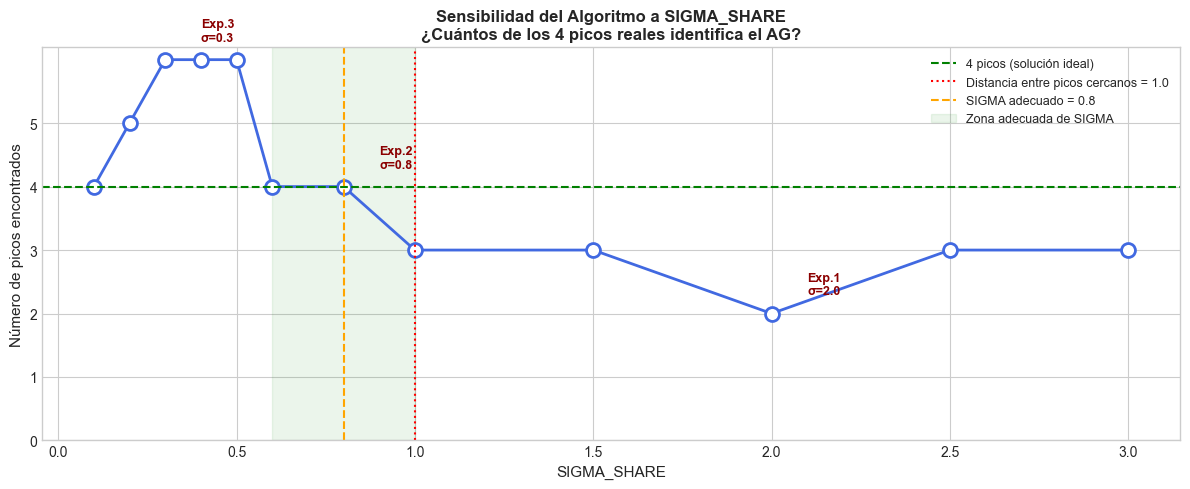


📊 Interpretación del gráfico de sensibilidad:
  - SIGMA muy bajo  (< 0.4): sin penalización real → converge al mejor pico
  - SIGMA adecuado (0.6-1.0): identifica los 4 picos correctamente
  - SIGMA muy alto  (> 1.5): fusiona picos cercanos → pierde resolución multimodal


In [10]:
# ============================================================
# GRÁFICO DE SENSIBILIDAD: PICOS ENCONTRADOS vs SIGMA_SHARE
# ============================================================

# Experimentar con múltiples valores de SIGMA para ver la sensibilidad
sigmas_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
picos_encontrados = []

print('Análisis de sensibilidad — calculando...')
for s in sigmas_test:
    _, _, _, _, ox, _ = run_ag(s, verbose=False)
    picos_encontrados.append(len(ox))
    print(f'  SIGMA={s:.2f} → {len(ox)} picos detectados')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sigmas_test, picos_encontrados, 'o-', color='royalblue',
        linewidth=2, markersize=10, markerfacecolor='white', markeredgewidth=2)
ax.axhline(4, color='green', linestyle='--', linewidth=1.5,
           label='4 picos (solución ideal)')
ax.axvline(1.0, color='red', linestyle=':', linewidth=1.5,
           label='Distancia entre picos cercanos = 1.0')
ax.axvline(0.8, color='orange', linestyle='--', linewidth=1.5,
           label='SIGMA adecuado = 0.8')
ax.axvspan(0.6, 1.0, alpha=0.08, color='green', label='Zona adecuada de SIGMA')

# Anotar los 3 experimentos
for s, etq in [(2.0, 'Exp.1\nσ=2.0'), (0.8, 'Exp.2\nσ=0.8'), (0.3, 'Exp.3\nσ=0.3')]:
    idx = sigmas_test.index(s)
    ax.annotate(etq, xy=(s, picos_encontrados[idx]),
                xytext=(s + 0.1, picos_encontrados[idx] + 0.3),
                fontsize=9, color='darkred', fontweight='bold')

ax.set_title('Sensibilidad del Algoritmo a SIGMA_SHARE\n'
             '¿Cuántos de los 4 picos reales identifica el AG?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('SIGMA_SHARE', fontsize=11)
ax.set_ylabel('Número de picos encontrados', fontsize=11)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('\n📊 Interpretación del gráfico de sensibilidad:')
print('  - SIGMA muy bajo  (< 0.4): sin penalización real → converge al mejor pico')
print('  - SIGMA adecuado (0.6-1.0): identifica los 4 picos correctamente')
print('  - SIGMA muy alto  (> 1.5): fusiona picos cercanos → pierde resolución multimodal')

---
# PARTE 4 — Planteamiento en Entorno Laboral
## Grupo 3 — Integrantes

| # | Estudiante | Planteamiento |
|---|---|---|
| 1 | **César Nelson Abarca Araujo** | Optimización de configuración de infraestructura de red corporativa |
| 2 | **Jorge Armando Quizamanchuro Fuel** | Optimización de arquitectura y configuración de una plataforma SaaS multi-tenant |
| 3 | **Robinson Damián Chiluisa Gallardo** | Optimización de diseño aerodinámico de superficies mediante computación evolutiva |

**Requisitos por planteamiento:**
- Definición de la función objetivo
- Estructura del cromosoma: genes, genotipo y fenotipo

---

## 👤 Miembro 1 — César Nelson Abarca Araujo
### Optimización de Configuración de Infraestructura de Red Corporativa

**Contexto:** En empresas medianas y grandes, la configuración de la infraestructura de red (ancho de banda asignado por segmento, priorización de tráfico QoS, número de nodos activos, redundancia de enlaces) es un problema con cientos de combinaciones posibles. Una mala configuración genera cuellos de botella, latencia alta y costos innecesarios. El objetivo es encontrar la configuración óptima que maximice el rendimiento minimizando el costo operativo.

**Función Objetivo:**

$$f(x) = w_1 \cdot \frac{Throughput(x)}{Throughput_{max}} - w_2 \cdot \frac{Latencia(x)}{Latencia_{max}} - w_3 \cdot \frac{Costo(x)}{Costo_{max}} + w_4 \cdot Redundancia(x)$$

Donde:
- $Throughput(x)$ = capacidad de transferencia efectiva de la configuración
- $Latencia(x)$ = latencia promedio entre nodos críticos
- $Costo(x)$ = costo mensual de la infraestructura configurada
- $Redundancia(x)$ = nivel de tolerancia a fallos (0 a 1)
- $w_1=0.4, w_2=0.3, w_3=0.2, w_4=0.1$ = pesos según prioridad del negocio
- **Penalización:** si la latencia supera el SLA → $-500$ puntos
- **Objetivo:** MAXIMIZAR (mayor rendimiento, menor costo, mayor redundancia)

**Estructura del Cromosoma:**

| Gen | Característica | Tipo | Rango / Valores posibles |
|---|---|---|---|
| G1 | Ancho de banda segmento oficinas (Mbps) | Entero | 100, 200, 500, 1000 |
| G2 | Ancho de banda segmento servidores (Mbps) | Entero | 1000, 2500, 5000, 10000 |
| G3 | Prioridad QoS para tráfico VoIP | Entero (1–5) | 1=Baja, 5=Crítica |
| G4 | Número de switches de distribución activos | Entero | 2, 4, 6, 8 |
| G5 | Tipo de enlace WAN principal | Categórico | 1=MPLS, 2=SD-WAN, 3=Fibra Dedicada |
| G6 | Redundancia de enlace (activo-activo o activo-pasivo) | Binario | 0=sin redundancia, 1=con redundancia |
| G7 | Segmentación VLAN por departamento | Entero | 4, 8, 16, 32 VLANs |
| G8 | Protocolo de enrutamiento interno | Categórico | 1=OSPF, 2=BGP, 3=EIGRP |

**Genotipo:** `[500, 5000, 4, 4, 2, 1, 16, 1]`

**Fenotipo:** *"Red con 500 Mbps para oficinas, 5 Gbps para servidores, QoS VoIP en prioridad alta, 4 switches activos, SD-WAN, con redundancia activo-activo, 16 VLANs, protocolo OSPF"*

**Por qué AG con Fitness Sharing (multimodal):** Existen múltiples configuraciones óptimas dependiendo de la ubicación geográfica de la oficina (Quito vs. Guayaquil vs. Cuenca). El Fitness Sharing permite encontrar la configuración óptima para **cada sede** simultáneamente, sin que una sede "consuma" todas las soluciones del espacio de búsqueda.

---

## 👤 Miembro 2 — Jorge Armando Quizamanchuro Fuel
### Optimización de Arquitectura y Configuración de Plataforma SaaS Multi-Tenant

**Contexto:** En el desarrollo de una plataforma SaaS multi-tenant con arquitectura basada en microservicios (NestJS + React Native + Nx Monorepo), la selección de parámetros de configuración para cada módulo afecta directamente el rendimiento, la escalabilidad y el costo operativo en producción. Variables como el número de réplicas por servicio, los límites de memoria, el tipo de base de datos por tenant y la estrategia de caché determinan si la plataforma puede escalar eficientemente bajo carga real. Con decenas de microservicios y múltiples combinaciones posibles, un AG permite encontrar la configuración de despliegue óptima sin evaluar todas las combinaciones manualmente.

**Función Objetivo:**

$$f(x) = w_1 \cdot P_{norm}(x) + w_2 \cdot S_{norm}(x) - w_3 \cdot C_{norm}(x) - w_4 \cdot L_{norm}(x)$$

Donde:
- $P_{norm}(x)$ = rendimiento normalizado: requests/segundo / requests_max
- $S_{norm}(x)$ = puntuación de escalabilidad según estrategia elegida (0–1)
- $C_{norm}(x)$ = costo mensual de infraestructura / costo_máximo_tolerable
- $L_{norm}(x)$ = latencia promedio p95 / latencia_SLA
- $w_1=0.35, w_2=0.30, w_3=0.20, w_4=0.15$
- **Penalización fuerte:** si la latencia p95 > 200ms → $-1000$ puntos
- **Penalización moderada:** si el costo supera el presupuesto definido → $-300$ puntos
- **Objetivo:** MAXIMIZAR (mayor rendimiento y escalabilidad, menor costo y latencia)

**Estructura del Cromosoma:**

| Gen | Característica del microservicio/plataforma | Tipo | Rango / Valores posibles |
|---|---|---|---|
| G1 | Número de réplicas del servicio API principal (NestJS) | Entero | 1, 2, 4, 8 |
| G2 | Límite de memoria RAM por pod (MB) | Entero | 256, 512, 1024, 2048 |
| G3 | Estrategia de aislamiento de base de datos por tenant | Categórico | 1=Schema-per-tenant, 2=DB-per-tenant, 3=Row-level |
| G4 | Proveedor de caché distribuida | Categórico | 1=Redis, 2=Memcached, 3=Sin caché |
| G5 | TTL de caché en segundos | Entero | 60, 300, 900, 3600 |
| G6 | Estrategia de escalado automático | Categórico | 1=HPA (CPU), 2=HPA (memoria), 3=KEDA (eventos) |
| G7 | Tipo de balanceador de carga | Categórico | 1=Round-Robin, 2=Least-Connections, 3=IP-Hash |
| G8 | Número de workers del proceso Node.js | Entero | 1, 2, 4, 8 |
| G9 | Habilitación de connection pooling en Prisma | Binario | 0=Deshabilitado, 1=Habilitado |
| G10 | Tamaño del pool de conexiones DB | Entero | 5, 10, 20, 50 |

**Genotipo:** `[4, 1024, 1, 1, 300, 3, 2, 4, 1, 20]`

**Fenotipo:** *"4 réplicas NestJS con 1GB RAM, aislamiento por schema por tenant, Redis como caché con TTL 5min, autoescalado por eventos (KEDA), balanceo Least-Connections, 4 workers Node.js, connection pooling Prisma activado con pool de 20 conexiones"*

**Por qué AG con Fitness Sharing (multimodal):** En una plataforma SaaS multi-tenant existen múltiples perfiles de carga óptimos: un tenant con uso intensivo de base de datos necesita una configuración diferente a uno con uso intensivo de API. El Fitness Sharing permite mantener **subpoblaciones de configuraciones óptimas para cada perfil de tenant** simultáneamente, en lugar de converger a una sola configuración que puede no ser óptima para todos.

---

## 👤 Miembro 3 — Robinson Damián Chiluisa Gallardo
### Optimización de Diseño Aerodinámico de Superficies mediante Computación Evolutiva

**Contexto:** En ingeniería aeronáutica, automotriz o de energía eólica, el diseño de superficies aerodinámicas (perfiles de ala, palas de turbina, carrocerías) implica encontrar la geometría que minimice la resistencia al avance (drag) y maximice la sustentación (lift). Cada parámetro geométrico de la superficie (curvatura, espesor, ángulo de ataque) afecta el comportamiento aerodinámico de forma no lineal y con múltiples óptimos locales. Esto lo convierte en un problema multimodal ideal para AG con Fitness Sharing.

**Función Objetivo:**

$$f(x) = w_1 \cdot \frac{C_L(x)}{C_{L,max}} - w_2 \cdot \frac{C_D(x)}{C_{D,max}} + w_3 \cdot \frac{C_L(x)/C_D(x)}{(C_L/C_D)_{max}}$$

Donde:
- $C_L(x)$ = coeficiente de sustentación (lift) del perfil con geometría $x$
- $C_D(x)$ = coeficiente de resistencia (drag) del perfil con geometría $x$
- $C_L/C_D$ = eficiencia aerodinámica (ratio de planeo)
- $w_1=0.3, w_2=0.4, w_3=0.3$ = pesos según aplicación (vehículo, avión, turbina)
- **Penalización estructural:** si el espesor máximo < umbral mínimo → $-800$ puntos
- **Penalización de separación:** si el ángulo de ataque provoca desprendimiento de capa límite → $-1000$ puntos
- **Objetivo:** MAXIMIZAR la eficiencia aerodinámica (mayor sustentación, menor resistencia)

**Estructura del Cromosoma (Parametrización NACA modificada):**

| Gen | Característica geométrica del perfil | Tipo | Rango / Valores |
|---|---|---|---|
| G1 | Curvatura máxima (camber) en % de la cuerda | Real | 0.0 – 9.0% |
| G2 | Posición de curvatura máxima (% de la cuerda) | Real | 10% – 90% |
| G3 | Espesor máximo (% de la cuerda) | Real | 6% – 24% |
| G4 | Ángulo de ataque (grados) | Real | -5° – 20° |
| G5 | Radio del borde de ataque (% de la cuerda) | Real | 0.5% – 5.0% |
| G6 | Ángulo del borde de salida (grados) | Real | 0° – 15° |
| G7 | Relación de aspecto de la superficie (envergadura/cuerda) | Real | 4.0 – 12.0 |
| G8 | Número de Mach de diseño | Real | 0.1 – 0.85 |

**Genotipo:** `[2.4, 40.0, 12.0, 5.0, 1.6, 6.0, 8.0, 0.3]`

**Fenotipo:** *"Perfil alar con curvatura 2.4% a 40% de la cuerda, espesor 12%, ángulo de ataque 5°, radio de borde de ataque 1.6%, borde de salida 6°, relación de aspecto 8:1, diseñado para Mach 0.3 (velocidad crucero de avión ligero)"*

**Por qué AG con Fitness Sharing (multimodal):** El paisaje aerodinámico tiene múltiples óptimos: un perfil óptimo para baja velocidad (planeador) es diferente al óptimo para alta velocidad (jet). El Fitness Sharing permite que el AG mantenga **subpoblaciones de diseños óptimos para cada régimen de vuelo** sin que el perfil de alta velocidad elimine al de baja velocidad durante la evolución.

In [11]:
# ============================================================
# ILUSTRACIÓN DE LOS 3 CROMOSOMAS — UN INDIVIDUO DE EJEMPLO
# POR CADA MIEMBRO DEL GRUPO 3
# ============================================================

import random as rnd

# ─────────────────────────────────────────────────────────────
# MIEMBRO 1 — César Abarca: Red Corporativa
# ─────────────────────────────────────────────────────────────
genes_red = [
    ('G1 - BW Oficinas (Mbps)',         [100, 200, 500, 1000]),
    ('G2 - BW Servidores (Mbps)',        [1000, 2500, 5000, 10000]),
    ('G3 - Prioridad QoS VoIP (1-5)',    [1, 2, 3, 4, 5]),
    ('G4 - Switches activos',            [2, 4, 6, 8]),
    ('G5 - Tipo WAN',                    ['MPLS', 'SD-WAN', 'Fibra']),
    ('G6 - Redundancia',                 ['Sin', 'Con']),
    ('G7 - VLANs',                       [4, 8, 16, 32]),
    ('G8 - Protocolo enrutamiento',      ['OSPF', 'BGP', 'EIGRP']),
]
ejemplo_red    = [500, 5000, 4, 4, 'SD-WAN', 'Con', 16, 'OSPF']
fenotipo_red   = ('500 Mbps oficinas | 5 Gbps servidores | QoS nivel 4 | '
                  '4 switches | SD-WAN | Redundancia activa | 16 VLANs | OSPF')

print('═' * 68)
print(' MIEMBRO 1 — César Abarca: Infraestructura de Red Corporativa')
print('═' * 68)
print(f'  Genotipo : {ejemplo_red}')
print(f'  Fenotipo : {fenotipo_red}')
print(f'  Fitness  : f(x) = 0.4·Throughput - 0.3·Latencia - 0.2·Costo + 0.1·Redundancia')
print(f'  Objetivo : MAXIMIZAR rendimiento de red minimizando costo operativo')
print()

# Simular 5 individuos para la población inicial
header_red = f"  {'Individuo':^10} | {'BW_OF':^8} | {'BW_SRV':^8} | {'QoS':^5} | {'SW':^4} | {'WAN':^8} | {'VLAN':^5}"
print(header_red)
print('  ' + '-'*60)
rnd.seed(10)
for i in range(5):
    bw_of  = rnd.choice([100,200,500,1000])
    bw_srv = rnd.choice([1000,2500,5000,10000])
    qos    = rnd.choice([1,2,3,4,5])
    sw     = rnd.choice([2,4,6,8])
    wan    = rnd.choice(['MPLS','SD-WAN','Fibra'])
    vlan   = rnd.choice([4,8,16,32])
    print(f'  {"Ind."+str(i+1):^10} | {bw_of:^8} | {bw_srv:^8} | {qos:^5} | {sw:^4} | {wan:^8} | {vlan:^5}')

# ─────────────────────────────────────────────────────────────
# MIEMBRO 2 — Jorge Quizamanchuro: Plataforma SaaS Multi-Tenant
# ─────────────────────────────────────────────────────────────
ejemplo_saas = [4, 1024, 'Schema-per-tenant', 'Redis', 300,
                'KEDA', 'Least-Connections', 4, 1, 20]
fenotipo_saas = ('4 réplicas NestJS | 1GB RAM/pod | Schema-per-tenant | '
                 'Redis TTL=300s | Autoescalado KEDA | Least-Conn | '
                 '4 workers Node | Pool Prisma=20 conexiones')

print()
print('═' * 68)
print(' MIEMBRO 2 — Jorge Quizamanchuro: Plataforma SaaS Multi-Tenant')
print('═' * 68)
print(f'  Genotipo : {ejemplo_saas}')
print(f'  Fenotipo : {fenotipo_saas}')
print(f'  Fitness  : f(x) = 0.35·Rendimiento + 0.30·Escalabilidad')
print(f'                   - 0.20·Costo - 0.15·Latencia_p95')
print(f'  Penaliz. : -1000 si latencia_p95 > 200ms | -300 si costo > presupuesto')
print(f'  Objetivo : MAXIMIZAR throughput y escalabilidad con mínimo costo')
print()

# Simular 5 individuos para la población inicial
replicas_opts  = [1, 2, 4, 8]
ram_opts       = [256, 512, 1024, 2048]
db_opts        = ['Schema', 'DB-per', 'Row-lvl']
cache_opts     = ['Redis', 'Memcached', 'Sin-caché']
ttl_opts       = [60, 300, 900, 3600]
escale_opts    = ['HPA-CPU', 'HPA-RAM', 'KEDA']
pool_opts      = [5, 10, 20, 50]

header_saas = f"  {'Individuo':^10} | {'Replicas':^9} | {'RAM(MB)':^8} | {'DB-Isol':^9} | {'Cache':^10} | {'Pool':^5}"
print(header_saas)
print('  ' + '-'*60)
rnd.seed(20)
for i in range(5):
    rep  = rnd.choice(replicas_opts)
    ram  = rnd.choice(ram_opts)
    db   = rnd.choice(db_opts)
    cach = rnd.choice(cache_opts)
    pool = rnd.choice(pool_opts)
    print(f'  {"Ind."+str(i+1):^10} | {rep:^9} | {ram:^8} | {db:^9} | {cach:^10} | {pool:^5}')

# ─────────────────────────────────────────────────────────────
# MIEMBRO 3 — Robinson Chiluisa: Diseño Aerodinámico
# ─────────────────────────────────────────────────────────────
ejemplo_aero = [2.4, 40.0, 12.0, 5.0, 1.6, 6.0, 8.0, 0.3]
fenotipo_aero = ('Camber 2.4% @ 40% cuerda | Espesor 12% | '
                 'Ataque 5° | R.ataque 1.6% | Salida 6° | Asp. 8:1 | Mach 0.3')

print()
print('═' * 68)
print(' MIEMBRO 3 — Robinson Chiluisa: Diseño Aerodinámico de Superficies')
print('═' * 68)
print(f'  Genotipo : {ejemplo_aero}')
print(f'  Fenotipo : {fenotipo_aero}')
print(f'  Fitness  : f(x) = 0.3·(CL/CL_max) - 0.4·(CD/CD_max) + 0.3·(CL/CD / ef_max)')
print(f'  Penaliz. : -800 si espesor < umbral | -1000 si desprendimiento capa límite')
print(f'  Objetivo : MAXIMIZAR eficiencia aerodinámica CL/CD (relación sustentación/resistencia)')
print()

# Simular 5 individuos para la población inicial (valores reales continuos)
rnd.seed(30)
header_aero = f"  {'Individuo':^10} | {'Camber_pct':^10} | {'Espesor_pct':^11} | {'Ataque_deg':^10} | {'Asp':^5} | {'Mach':^6}"
print(header_aero)
print('  ' + '-'*58)
for i in range(5):
    camber  = round(rnd.uniform(0.0, 9.0), 2)
    grosor  = round(rnd.uniform(6.0, 24.0), 2)
    ataque  = round(rnd.uniform(-5.0, 20.0), 2)
    aspecto = round(rnd.uniform(4.0, 12.0), 1)
    mach    = round(rnd.uniform(0.1, 0.85), 2)
    print(f'  {"Ind."+str(i+1):^10} | {camber:^8} | {grosor:^9} | {ataque:^8} | {aspecto:^5} | {mach:^6}')

print()
print('═' * 68)
print(' COMPARATIVA DE CROMOSOMAS POR MIEMBRO')
print('═' * 68)
print(f'  Miembro  | Tipo genes | N° genes | Codif.    | Espacio búsqueda')
print('  ' + '-'*65)
print(f'  César    | Mixto      |    8     | Int+Cat   | ~3×10⁴ combinaciones')
print(f'  Jorge    | Mixto      |   10     | Int+Cat   | ~5×10⁵ combinaciones')
print(f'  Robinson | Real       |    8     | Continuo  | Infinito (espacio ℝ⁸)')
print('═' * 68)

════════════════════════════════════════════════════════════════════
 MIEMBRO 1 — César Abarca: Infraestructura de Red Corporativa
════════════════════════════════════════════════════════════════════
  Genotipo : [500, 5000, 4, 4, 'SD-WAN', 'Con', 16, 'OSPF']
  Fenotipo : 500 Mbps oficinas | 5 Gbps servidores | QoS nivel 4 | 4 switches | SD-WAN | Redundancia activa | 16 VLANs | OSPF
  Fitness  : f(x) = 0.4·Throughput - 0.3·Latencia - 0.2·Costo + 0.1·Redundancia
  Objetivo : MAXIMIZAR rendimiento de red minimizando costo operativo

  Individuo  |  BW_OF   |  BW_SRV  |  QoS  |  SW  |   WAN    | VLAN 
  ------------------------------------------------------------
    Ind.1    |   100    |  10000   |   4   |  2   |   MPLS   |  32  
    Ind.2    |   1000   |   5000   |   2   |  2   |  Fibra   |  32  
    Ind.3    |   500    |   1000   |   2   |  6   |   MPLS   |  32  
    Ind.4    |   200    |   5000   |   4   |  8   |  SD-WAN  |  16  
    Ind.5    |   1000   |   2500   |   3   |  6   |   M

---
# Conclusiones Generales

## Sobre el Fitness Sharing y los Problemas Multimodales

Los Algoritmos Genéticos por sí solos tienden a converger al óptimo global más alto, descartando picos menores. El **Fitness Sharing** resuelve esto penalizando a los individuos que compiten por el mismo nicho, permitiendo que múltiples subpoblaciones se mantengan estables alrededor de diferentes picos simultáneamente.

## Sobre el Impacto de SIGMA_SHARE

| SIGMA_SHARE | Efecto observado | Recomendación |
|---|---|---|
| **2.0** (grande) | Fusiona los picos cercanos (x=1.5 y x=2.5). Solo detecta 2 picos. | Evitar si existen picos separados menos que σ |
| **0.8** (adecuado) | Distingue todos los 4 picos. Subpoblaciones estables en cada pico. | **Valor recomendado** para esta función |
| **0.3** (pequeño) | Nichos muy pequeños, penalización irrelevante. Converge al pico mayor. | Evitar si se desea exploración multimodal real |

**Regla práctica:** SIGMA_SHARE ≈ 0.6–0.9 × (distancia mínima entre picos).

## Conexión con la Teoría Vista en Clase

- **Niching** es la implementación computacional del principio de diversidad biológica: en la naturaleza, especies distintas coexisten en nichos diferentes sin competir directamente.
- El **problema multimodal** es análogo al ejercicio de selección de personal con candidatos de diferentes ciudades: el Niching permite identificar al mejor candidato en cada ciudad (nicho), en lugar de solo el mejor global.
- El parámetro SIGMA_SHARE es el equivalente computacional de la **distancia de Hamming** en algoritmos CHC: define qué tan diferentes deben ser dos individuos para no penalizarse mutuamente.